In [1]:
%%bash
git clone https://github.com/ahaberlie/SVRIMG.git > /dev/null
cd SVRIMG && pip install . > /dev/null

Cloning into 'SVRIMG'...


In [2]:
from svrimg.utils.get_images import get_example_data

(x_train, y_train) = get_example_data('training', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_val, y_val) = get_example_data('validation', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_test, y_test) = get_example_data('testing', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")

# L12 - Convolutional Neural Networks (Forward Pass)

Directions:

1. Please rename the file by clicking on “LX-First-Last.ipynb” where X is the lab number, and replace First and Last with your first and last name.

2. Click File -> Save to make sure your most recent edits are saved.

3. In the upper right hand corner of the screen, click on “Share”. Click on “Restricted” and change it to “Anyone with the link”. Make sure you also share it with `ahaberlie1@gmail.com`.

4. Copy the link and submit it on Blackboard. Make sure you follow these steps completely, or I will be unable to grade your work.

### Overview

This lab will help you understand tensorflow and its basic methods. We will walk through some examples of how tensorflow can help solve Geoscience problems. Periodically, I will 1) ask you to either repeat the demonstrated code in a slightly different way; or 2) ask you to combine two or more techniques to solve a problem.

You can use generative AI to help answer these problems. **The answer should still be in your own words.** Think of the generative AI descriptions as those from a book. You still have to cite your source and you cannot plagiarize directly from the source. For every question that you used generative AI for help, please reference the generative AI you used and what your prompt or prompts were.

However, it is crucial that you understand the code well enough to effectively use generative AI tools that are likely to be widely available and recommended for use at many organizations. Although they are improving at an incredible rate, they still produce bugs, especially with domain-specific and complex problems. Make sure that you verify the answers before putting them in your own words.

### tensorflow

This package, sometimes called ["tf"](https://www.tensorflow.org/learn/), provides an interface to many methods for digital image classification. It allows you to work with both RGB (3, y, x) and grayscale images (y, x). We will practice some techniques using grayscale images in this lab.

### Overview

Starting with an input image, perform a series of convolution and max pooling steps that result in the following dimensions after each step. For convolution, use `mode=valid`.

### Problem 1

Pick an input image from `x_train` and make sure the dimensions are 136,136. The original dimensions are `(number_of_samples, y_size, x_size, channel_num)`. This requires you to use simple numpy indexing to pick *one* image and *one* channel, but keep *all* of the `y` and `x` data. Right now there is just a random image that is generated--you need to replace that code with a specific image in `x_train`.


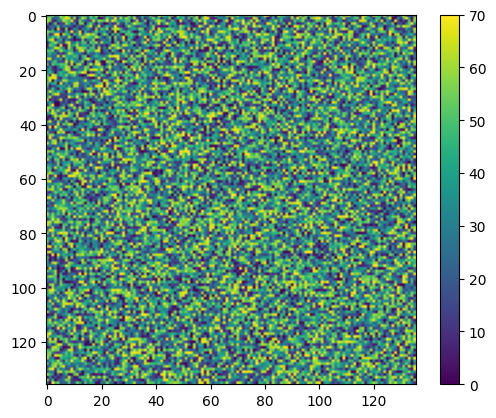

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# change this to get an image from x_train
my_img = np.random.randint(0, 71, size=(136, 136), dtype='uint8')

plt.imshow(my_img)
plt.colorbar()

### Problem 2

Define the following filters:

1. Edge detector (any direction you want)
2. Sharpen
3. Blur

The default filters are random 3x3 arrays below, you need to change them into specific numpy arrays based on the textbook material.

NOTE: In a real CNN, these filters will initially be random and automatically optimized to improve model performance. In other words, you will not have to engineer filters in practice if you are using a CNN. However, it is good to know how they work if you ever have to interpret / troubleshoot a CNN.

In [4]:
# Problem 2.1
edge = np.array([[1, 4, 9],
                 [5, 0, 1],
                 [12, 0, -5]])

# Problem 2.2
sharpen = np.array([[-9, 4, 1],
                    [-5, 1, 3],
                    [8, 1, 1]])

# Problem 2.3
blur = np.array([[0, 0, 11],
                 [-10, -5, 5],
                 [1, 5, -2]])

### Problem 3

Complete the max pooling function. The current function below converts each 3x3 neighborhood to 1 pixel representing the mean of the neighborhood. Modify the code to instead use the maximum of that neighborhood. The rest of the function should remain exactly as it is below:

In [5]:
def max_pool_3x3(x):
    '''Transforms an image by turning each 3x3 pixel neighborhood
    into 1 pixel by calculating the maximum value in that neighborhood
    and placing it in the transformed image in the position representative
    of the original neighborhood's position.

    Parameters
    --------------------------
    x: numpy ndarray
        image to transform

    Returns
    --------------------------
    pooled: numpy ndarray
        transformed image
    '''
    h, w = x.shape

    out_h = h // 3
    out_w = w // 3

    pooled = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            neighborhood = x[i*3:i*3+3, j*3:j*3+3]

            # Problem 3
            pooled[i, j] = np.min(neighborhood)

    return pooled

### Problem 4

Convolution + Pooling step 1

1. Apply the edge detection filter to the original image using convolution and set the result to a variable named `conv1`. Use `mode=valid`.
2. Apply the relu activation function and set the result to a variable named `act1`.
    - $act1 = maximum(0, x)$
2. Pass the convolved image into the max_pool_3x3 method and set the result to a variable named `pool1`
3. Visualize the result of `conv1` and `pool1` and print the shape of `conv1` and `pool1`.

NOTE: `np.max` and `np.maximum` do slightly different things. In the `ReLU` case, we want to use `np.maximum` to compare every value in `conv1` to 0. If it is above zero, keep the value, if not set it to 0. This removes negative values and generally results in a better performing model.

Conv 1: (136, 136)
Pool 1: (136, 136)


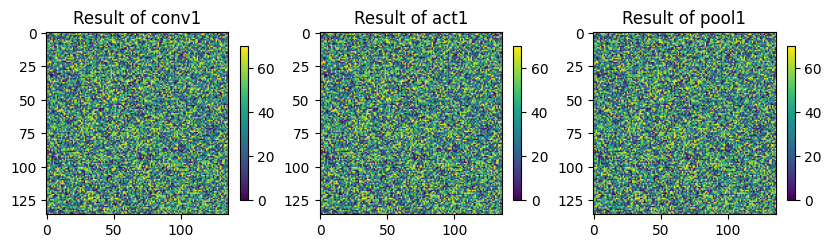

In [6]:
from scipy.signal import convolve2d

plt.rcParams['figure.figsize'] = 10, 10

# Problem 4.1
conv1 = my_img

# Problem 4.2
act1 = conv1

# Problem 4.3
pool1 = act1

ax = plt.subplot(1, 3, 1)
ax.set_title("Result of conv1")
mmp = ax.imshow(conv1)
plt.colorbar(mmp, ax=ax, shrink=0.2)

ax = plt.subplot(1, 3, 2)
ax.set_title("Result of act1")
mmp = ax.imshow(act1)
plt.colorbar(mmp, ax=ax, shrink=0.2)

ax = plt.subplot(1, 3, 3)
ax.set_title("Result of pool1")
mmp = ax.imshow(pool1)
plt.colorbar(mmp, ax=ax, shrink=0.2)

print("Conv 1:", conv1.shape)
print("Pool 1:", pool1.shape)

What do you notice about the values in the convolution values?

**ANSWER:**

Eventually, these values will be passed into a dense layer that will apply weights to each input from the representation after step 3 below. As we noted from our discussion of the activation function (ReLU), these large values can produce large positive activations because ReLU does not cap positive values. In other words, it only clips negative values to 0. For this reason, input data are typically normalized or standardized on a consistent scale and often centered near 0. Thus, we want to first normalize the input data using your choice of normalization and then rerun the first step and continue with subsequent steps using the normalized input:

### Problem 5

Calculate the min and max in `x_train` and normalize `my_img` using Min/Max normalization.

$x_{norm}​= (x_{sample} - x_{min}) / ​(x_{max} − x_{min}​​)$

In [7]:
max_value = np.max(x_train)
min_value = np.min(x_train)

# Problem 5
norm_img = my_img

print(np.min(norm_img), np.max(norm_img))

0 70


Include the modifications you made in **Problem 4** below and rerun the code using `norm_img`.

Conv 1: (136, 136)
Pool 1: (136, 136)


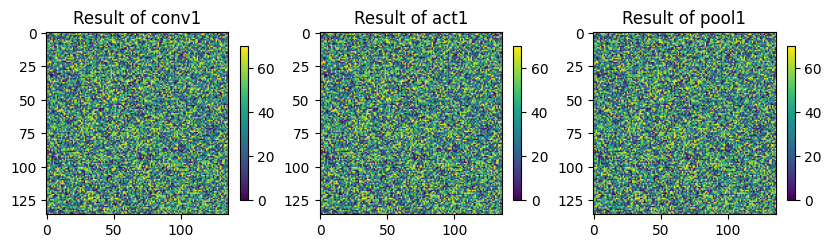

In [8]:
from scipy.signal import convolve2d

plt.rcParams['figure.figsize'] = 10, 10

# Problem 4.1
conv1 = norm_img

# Problem 4.2
act1 = conv1

# Problem 4.3
pool1 = act1

ax = plt.subplot(1, 3, 1)
ax.set_title("Result of conv1")
mmp = ax.imshow(conv1)
plt.colorbar(mmp, ax=ax, shrink=0.2)

ax = plt.subplot(1, 3, 2)
ax.set_title("Result of act1")
mmp = ax.imshow(act1)
plt.colorbar(mmp, ax=ax, shrink=0.2)

ax = plt.subplot(1, 3, 3)
ax.set_title("Result of pool1")
mmp = ax.imshow(pool1)
plt.colorbar(mmp, ax=ax, shrink=0.2)

print("Conv 1:", conv1.shape)
print("Pool 1:", pool1.shape)

### Problem 6

Repeat the steps using `pool1` instead of `norm_img` by:

1. Convolve using a blur filter on `pool1` and set the result equal to `conv2`
2. Run the `ReLU` activation function on `conv2` and set the result equal to `act2`
3. Pool the result of `act2` using max_pool_3x3 and save the result in `pool2`

The printed result below should display:

```
Conv 2: (42, 42)
Pool 2: (14, 14)
```

Conv 2: (136, 136)
Pool 2: (136, 136)


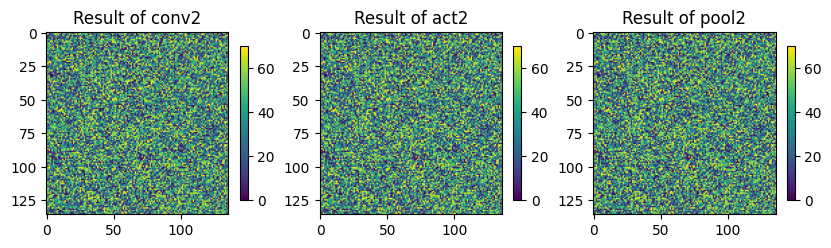

In [9]:
plt.rcParams['figure.figsize'] = 10, 10

# Problem 6.1
conv2 = pool1

# Problem 6.2
act2 = conv2

# Problem 6.3
pool2 = act2

ax = plt.subplot(1, 3, 1)
ax.set_title("Result of conv2")
mmp = ax.imshow(conv2)
plt.colorbar(mmp, ax=ax, shrink=0.2)

ax = plt.subplot(1, 3, 2)
ax.set_title("Result of act2")
mmp = ax.imshow(act2)
plt.colorbar(mmp, ax=ax, shrink=0.2)

ax = plt.subplot(1, 3, 3)
ax.set_title("Result of pool2")
mmp = ax.imshow(pool2)
plt.colorbar(mmp, ax=ax, shrink=0.2)

print("Conv 2:", conv2.shape)
print("Pool 2:", pool2.shape)

## Problem 7

Repeat the steps using `pool2` instead of `pool1` by:

1. Convolve using a sharpen filter on `pool2` and set the result equal to `conv3`
2. Run the `ReLU` activation function on `conv3` and set the result equal to `act3`
3. Pool the result of `act3` using max_pool_3x3 and save the result in `pool3`

The printed result below should display:

```
Conv 3: (12, 12)
Pool 3: (4, 4)
```

Conv 3: (136, 136)
Pool 3: (136, 136)


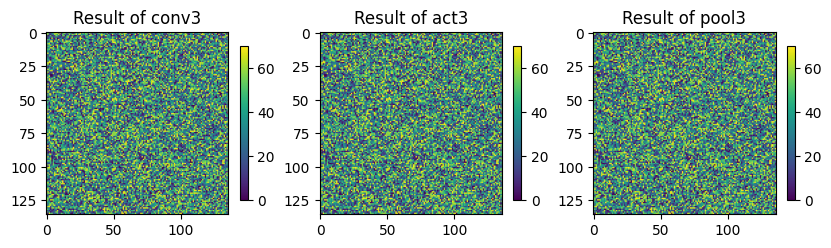

In [10]:
plt.rcParams['figure.figsize'] = 10, 10

# Problem 7.1
conv3 = pool2

# Problem 7.2
act3 = conv3

# Problem 7.3
pool3 = act3

ax = plt.subplot(1, 3, 1)
ax.set_title("Result of conv3")
mmp = ax.imshow(conv3)
plt.colorbar(mmp, ax=ax, shrink=0.2)

ax = plt.subplot(1, 3, 2)
ax.set_title("Result of act3")
mmp = ax.imshow(act3)
plt.colorbar(mmp, ax=ax, shrink=0.2)

ax = plt.subplot(1, 3, 3)
ax.set_title("Result of pool3")
mmp = ax.imshow(pool3)
plt.colorbar(mmp, ax=ax, shrink=0.2)

print("Conv 3:", conv3.shape)
print("Pool 3:", pool3.shape)

### Problem 8

Flatten `pool3` and set it equal to a variable named `flat1` and plot the result. Describe what these values represent and how they will be used in the dense layer.

The size should be `(16, 1)`.

**ANSWER:**

Flat 3: (18496,)


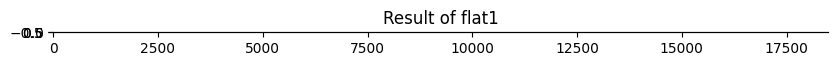

In [11]:
flat1 = pool3.flatten()

plt.title("Result of flat1")
plt.imshow([flat1])

print("Flat 3:", flat1.shape)